# 🧹 Exploratory Data Analysis & Preprocessing Pipeline
In this notebook, we will load the Titanic dataset, perform Exploratory Data Analysis (EDA), and apply the cleaning techniques discussed in our theory document.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Load the dataset
df = pd.read_csv('../Datasets/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 1: Initial Inspection
Let's look at the shape of the data and check for missing values.

In [9]:
print(f"Dataset Shape: {df.shape}\n")
print("Missing Values per Column:")
print(df.isnull().sum())

Dataset Shape: (891, 12)

Missing Values per Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Step 2: Visualizing Missing Data
Using Seaborn, we can create a heatmap to see exactly where the missing data is located. You will likely see that `Cabin` is mostly missing, and `Age` has a scattered amount of missing values.

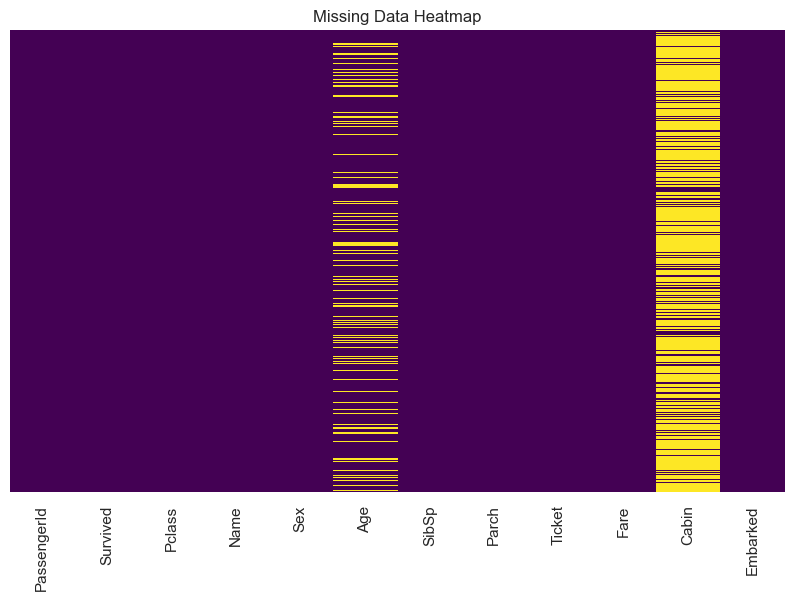

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

## Step 3: Handling Missing Values (Imputation & Deletion)
Based on the KDD principles in our theory document:
1. **Cabin**: Over 70% missing. We will drop this column entirely.
2. **Age**: Roughly 20% missing. We will impute this using the median age.
3. **Embarked**: Only 2 missing. We will fill these with the mode (most frequent port).

In [11]:
# 1. Drop 'Cabin'
df.drop('Cabin', axis=1, inplace=True)

# 2. Impute 'Age' with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# 3. Impute 'Embarked' with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Verify cleaning
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Step 4: Encoding Categorical Data
Now we need to convert strings into numbers so machine learning models can understand them. We'll use One-Hot Encoding for 'Sex' and 'Embarked'.

In [12]:
# We drop the first column to avoid the dummy variable trap
sex = pd.get_dummies(df['Sex'], drop_first=True, dtype=int)
embark = pd.get_dummies(df['Embarked'], drop_first=True, dtype=int)

# Add the new columns to the dataframe
df = pd.concat([df, sex, embark], axis=1)

# Drop the original string columns, plus columns we don't need for ML (Name, Ticket, PassengerId)
df.drop(['Sex', 'Embarked', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


## Step 5: Train-Test Split & Feature Scaling
Before we train our models, we must split our data so we have a "test" set to evaluate performance. We also apply `StandardScaler` so that features with large numerical ranges (like `Fare`) don't overpower smaller features.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data: 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the data using StandardScaler (Z-Score Normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (623, 8)
Testing data shape: (268, 8)


## Step 6: Model Training & Evaluation
We will train two models: a standard **Logistic Regression** (Linear) and a **Random Forest Classifier** (Tree-based ensemble). We will evaluate them using Precision, Recall, and the F1-Score.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- Logistic Regression ---
logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train_scaled, y_train)
log_predictions = logmodel.predict(X_test_scaled)

print("===== LOGISTIC REGRESSION =====")
print(classification_report(y_test, log_predictions))

# --- Random Forest ---
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train_scaled, y_train)
rfc_predictions = rfc.predict(X_test_scaled)

print("\n===== RANDOM FOREST =====")
print(classification_report(y_test, rfc_predictions))

===== LOGISTIC REGRESSION =====
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       157
           1       0.79      0.73      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268


===== RANDOM FOREST =====
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       157
           1       0.75      0.71      0.73       111

    accuracy                           0.78       268
   macro avg       0.78      0.77      0.78       268
weighted avg       0.78      0.78      0.78       268



## Step 7: Feature Importance
One of the best features of a Random Forest is its ability to tell us *which* variables were the most important when it made its decisions.

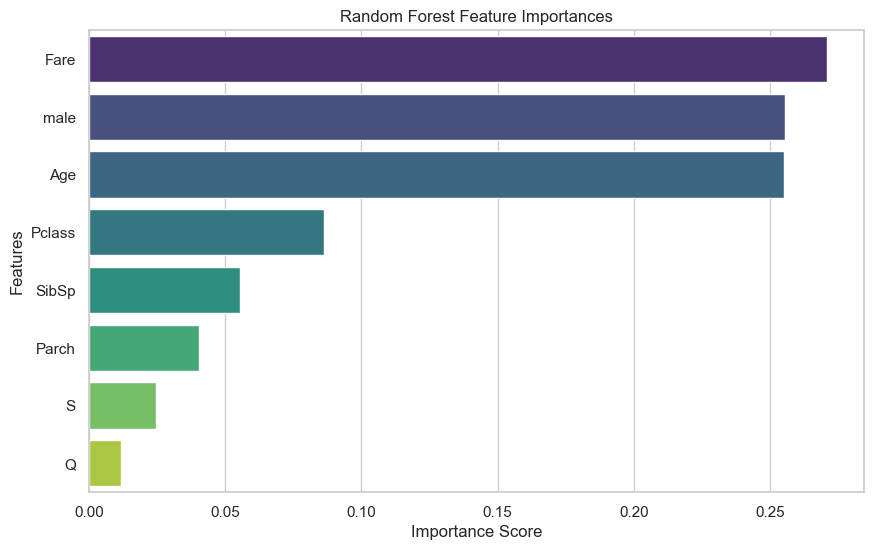

In [15]:
# Extract feature importances from the Random Forest model
feature_importances = pd.DataFrame(rfc.feature_importances_, index=X.columns, columns=['Importance'])
feature_importances = feature_importances.sort_values('Importance', ascending=False)

# Plot it visually
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances['Importance'], y=feature_importances.index, hue=feature_importances.index, palette='viridis', legend=False)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()